Preguntas a responder:

AutoML_Flaml para desempeño de modelos

In [58]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [59]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

df_bank = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_banko.parquet")

In [60]:
#y = df_bank["y"].map({'no': 0, 'yes': 1}) otra opcion
X = df_bank.drop(columns=["y"])
y = df_bank["y"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [61]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  float64 
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  object  
dtypes: category(9), float64(1), int64(6), object(1)
memory usage: 3.1+ MB


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [63]:
numeric_features = ["age", "balance", "day", "duration","campaign", "pdays","previous"]
categorical_features = ["job", "marital","default","housing","loan","contact","month","poutcome"]
ordinal_features = ["education"]


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[['tertiary', 'secondary', 'primary', 'unknown']]))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [64]:
from flaml import AutoML
from sklearn.pipeline import Pipeline as SKLearnPipeline

automl = AutoML()

In [65]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

X_test_preprocessed = preprocessor.fit_transform(X_test)

automl_settings = {
    "time_budget": 60,  # total running time in seconds
    "metric": 'accuracy',  # primary metric to optimize
    "task": 'classification',  # task type
    "estimator_list": ['lgbm', 'xgboost', 'lrl1', 'rf'],  # list of ML learners
    "log_file_name": 'flaml_banco_automl.log',  # flaml log file
    "seed": 42
}

automl.fit(X_train_preprocessed, y_train, **automl_settings)

[flaml.automl.logger: 11-03 16:42:55] {1752} INFO - task = classification
[flaml.automl.logger: 11-03 16:42:55] {1763} INFO - Evaluation method: holdout
[flaml.automl.logger: 11-03 16:42:55] {1862} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 11-03 16:42:55] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'lrl1', 'rf']
[flaml.automl.logger: 11-03 16:42:55] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 11-03 16:42:55] {2417} INFO - Estimated sufficient time budget=2140s. Estimated necessary time budget=35s.
[flaml.automl.logger: 11-03 16:42:55] {2466} INFO -  at 0.4s,	estimator lgbm's best error=0.1169,	best estimator lgbm's best error=0.1169
[flaml.automl.logger: 11-03 16:42:55] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 11-03 16:42:56] {2466} INFO -  at 0.5s,	estimator lgbm's best error=0.1169,	best estimator lgbm's best error=0.1169
[flaml.automl.logger: 11-03 16:42:56] {2282} INFO - iteration

c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 16:42:56] {2466} INFO -  at 0.6s,	estimator lgbm's best error=0.1163,	best estimator lgbm's best error=0.1163
[flaml.automl.logger: 11-03 16:42:56] {2282} INFO - iteration 3, current learner lgbm
[flaml.automl.logger: 11-03 16:42:56] {2466} INFO -  at 0.7s,	estimator lgbm's best error=0.1000,	best estimator lgbm's best error=0.1000
[flaml.automl.logger: 11-03 16:42:56] {2282} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 11-03 16:42:56] {2466} INFO -  at 0.9s,	estimator lgbm's best error=0.1000,	best estimator lgbm's best error=0.1000
[flaml.automl.logger: 11-03 16:42:56] {2282} INFO - iteration 5, current learner lgbm


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 16:42:56] {2466} INFO -  at 1.1s,	estimator lgbm's best error=0.1000,	best estimator lgbm's best error=0.1000
[flaml.automl.logger: 11-03 16:42:56] {2282} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 11-03 16:42:56] {2466} INFO -  at 1.1s,	estimator lgbm's best error=0.1000,	best estimator lgbm's best error=0.1000
[flaml.automl.logger: 11-03 16:42:56] {2282} INFO - iteration 7, current learner xgboost


...

[flaml.automl.logger: 11-03 16:43:45] {2466} INFO -  at 49.7s,	estimator rf's best error=0.1069,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:43:45] {2282} INFO - iteration 80, current learner rf
[flaml.automl.logger: 11-03 16:43:45] {2466} INFO -  at 49.9s,	estimator rf's best error=0.1047,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:43:45] {2282} INFO - iteration 81, current learner rf
[flaml.automl.logger: 11-03 16:43:45] {2466} INFO -  at 50.2s,	estimator rf's best error=0.1022,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:43:45] {2282} INFO - iteration 82, current learner rf
[flaml.automl.logger: 11-03 16:43:45] {2466} INFO -  at 50.5s,	estimator rf's best error=0.1022,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:43:45] {2282} INFO - iteration 83, current learner rf
[flaml.automl.logger: 11-03 16:43:46] {2466} INFO -  at 50.8s,	estimator rf's best error=0.0981,	best estimator 

c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 16:43:52] {2466} INFO -  at 56.9s,	estimator rf's best error=0.0967,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:43:52] {2282} INFO - iteration 95, current learner lgbm
[flaml.automl.logger: 11-03 16:43:52] {2466} INFO -  at 57.0s,	estimator lgbm's best error=0.0890,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:43:52] {2282} INFO - iteration 96, current learner xgboost


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 16:43:55] {2466} INFO -  at 59.7s,	estimator xgboost's best error=0.0901,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:43:55] {2282} INFO - iteration 97, current learner lrl1
[flaml.automl.logger: 11-03 16:43:59] {2466} INFO -  at 64.1s,	estimator lrl1's best error=0.1169,	best estimator lgbm's best error=0.0890
[flaml.automl.logger: 11-03 16:44:00] {2724} INFO - retrain lgbm for 0.5s
[flaml.automl.logger: 11-03 16:44:00] {2727} INFO - retrained model: LGBMClassifier(learning_rate=np.float64(0.24480510274870323), max_bin=127,
               min_child_samples=21, n_estimators=122, n_jobs=-1, num_leaves=18,
               reg_alpha=np.float64(0.0035181153245516846),
               reg_lambda=np.float64(0.01288289370679659), verbose=-1)
[flaml.automl.logger: 11-03 16:44:00] {2009} INFO - fit succeeded
[flaml.automl.logger: 11-03 16:44:00] {2010} INFO - Time taken to find the best model: 21.739353895187378


In [66]:
print("Mejor modelo encontrado", automl.best_estimator)

print("\n")

print("Mejor configuración de hiperparámetros:", automl.best_config)

print("\n")

print("Tiempo de búsqueda:", automl.time_to_find_best_model, "segundos")

Mejor modelo encontrado lgbm


Mejor configuración de hiperparámetros: {'n_estimators': 122, 'num_leaves': 18, 'min_child_samples': 21, 'learning_rate': np.float64(0.24480510274870323), 'log_max_bin': 7, 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.0035181153245516846), 'reg_lambda': np.float64(0.01288289370679659)}


Tiempo de búsqueda: 21.739353895187378 segundos


In [67]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = automl.predict(X_test_preprocessed)

y_pred_proba = automl.predict_proba(X_test_preprocessed)[:, 1]

c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [68]:
test_accuracy = accuracy_score(y_test, y_pred)

print("\n")

print(classification_report(y_test, y_pred, target_names=["No adquirió", "Adquirió"]))



              precision    recall  f1-score   support

 No adquirió       0.93      0.97      0.95      7973
    Adquirió       0.66      0.48      0.56      1070

    accuracy                           0.91      9043
   macro avg       0.80      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



<Axes: >

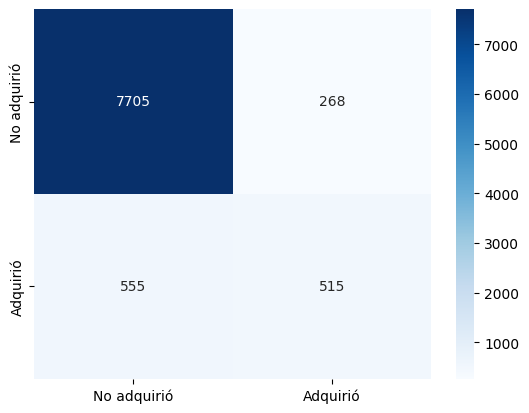

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No adquirió", "Adquirió"], yticklabels=["No adquirió", "Adquirió"])

In [70]:
df_predictions = X_test.copy()

In [71]:
X_test

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
20572,45,admin.,married,secondary,no,362.0,no,no,cellular,12,aug,536,4,-1,0,unknown
4543,37,housemaid,single,secondary,no,2042.0,yes,no,unknown,20,may,485,1,-1,0,unknown
34836,25,blue-collar,single,secondary,yes,15.0,yes,no,telephone,6,may,44,1,-1,0,unknown
40303,30,admin.,married,secondary,no,124.0,no,no,telephone,16,jun,161,2,-1,0,unknown
4379,42,self-employed,married,tertiary,no,596.0,yes,no,unknown,19,may,66,9,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24330,39,management,married,tertiary,no,500.0,yes,no,cellular,17,nov,257,1,178,2,other
36189,31,admin.,single,secondary,no,78.0,yes,no,cellular,11,may,360,1,370,1,other
38091,30,entrepreneur,married,primary,no,386.0,yes,no,cellular,15,may,253,4,-1,0,unknown
6222,24,technician,single,tertiary,no,1954.0,yes,yes,unknown,27,may,78,1,-1,0,unknown


In [72]:
df_predictions["adquiere_real"] = y_test.values

df_predictions["prediction_label"] = y_pred

df_predictions["prediction_score"] = y_pred_proba

print(df_predictions[['age', 'education','housing','adquiere_real', 'prediction_label', 'prediction_score']].sample(10))

       age  education housing adquiere_real prediction_label  prediction_score
35970   51  secondary     yes            no               no          0.038980
32209   42  secondary      no            no               no          0.003760
20891   56  secondary      no            no               no          0.001548
17159   51  secondary      no            no               no          0.000270
30011   45  secondary     yes           yes              yes          0.539381
44738   80  secondary      no           yes              yes          0.695721
43859   49   tertiary     yes           yes              yes          0.914914
14608   36   tertiary     yes            no               no          0.225966
980     42    primary     yes            no               no          0.000518
5936    32  secondary     yes            no               no          0.000192


Guardamos el modelo 1

In [73]:
full_pipeline = SKLearnPipeline(steps=[
    ("preprocessor", preprocessor),
    ("automl", automl.model)
])

print(full_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['tertiary',
                                                                          

In [74]:
import joblib 

model_filename = DATA_DIR / "lightgbm_flaml_automl_model.joblib"
joblib.dump(full_pipeline, model_filename)

['C:\\Users\\aical\\Documents\\JM_SD_SC_marketing_bancario\\datos\\lightgbm_flaml_automl_model.joblib']